# Emotion Text Classifier
### Final evaluation of the emotion classifier on unseen test data

### Introduction

In the previous notebooks, we developed and evaluated an emotion classification pipeline using TF-IDF features and classical machine learning models.

First, a baseline model based on Logistic Regression was implemented, achieving strong performance on the validation set. Then, a comparative analysis between Logistic Regression and Multinomial Naive Bayes showed that Logistic Regression significantly outperformed Naive Bayes, especially in handling class imbalance and capturing more nuanced distinctions between emotions.

Based on these results, Logistic Regression was selected as the final model.

In this notebook, we perform the final evaluation of this model on the held-out test set. This dataset has not been used at any stage of model training or selection, ensuring an unbiased estimate of the model's real-world performance.

To make the best use of the available data, the final model is retrained on the combined training and validation sets before being evaluated on the test set.

No further tuning or model selection is performed at this stage.

## Imports

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

import pandas as pd

from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

from src.data_loader import load_datasets
from src.preprocessing import add_clean_text_column
from src.features import split_features_labels, vectorize_datasets
from src.models.logistic_regression import train_logistic_regression

## 1. Load Dataset

In [2]:
DATA_PATH = Path("../data/raw/emotion_dataset")

train_df, val_df, test_df = load_datasets(DATA_PATH)

In [3]:
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (16000, 2)
Validation shape: (2000, 2)
Test shape: (2000, 2)


## 2. Text Preprocessing
#### We clean and normalize the text data by lowercasing and removing non-alphabetic characters

In [4]:
train_df = add_clean_text_column(train_df)
val_df = add_clean_text_column(val_df)
test_df = add_clean_text_column(test_df)

## Define Features and Labels

In [35]:
X_train, y_train = split_features_labels(train_df)
X_val, y_val = split_features_labels(val_df)
X_test, y_test = split_features_labels(test_df)

In [36]:
X_train_final = pd.concat([X_train, X_val], ignore_index=True)
y_train_final = pd.concat([y_train, y_val], ignore_index=True)

print("Final training size:", X_train_final.shape)
print("Test size:", X_test.shape)

Final training size: (18000,)
Test size: (2000,)


## 3. Feature Extraction with TF-IDF
#### We convert the cleaned text into numerical feature vectors using TF-IDF

In [37]:
X_train_final, _, X_test, vectorizer = vectorize_datasets(X_train_final, X_val, X_test)

In [38]:
print("X_train shape:", X_train_final.shape)
print("X_test shape:", X_test.shape)

X_train shape: (18000, 16170)
X_test shape: (2000, 16170)


## 4. Final Model Training
#### After selecting Logistic Regression as the best-performing model in the previous experiments, we now train the final version of the classifier using the combined training and validation data

In [39]:
lr_model = train_logistic_regression(X_train_final, y_train_final)
print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [40]:
y_test_pred = lr_model.predict(X_test)

## 5. Final Evaluation on the Test Set
#### We now evaluate the final Logistic Regression model on the held-out test set

In [41]:
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.8655

Classification Report:

              precision    recall  f1-score   support

       anger       0.90      0.82      0.86       275
        fear       0.87      0.77      0.82       224
         joy       0.84      0.96      0.89       695
        love       0.83      0.60      0.70       159
     sadness       0.90      0.93      0.91       581
    surprise       0.82      0.48      0.61        66

    accuracy                           0.87      2000
   macro avg       0.86      0.76      0.80      2000
weighted avg       0.87      0.87      0.86      2000



## Confusion Matrix
#### The confusion matrix shows correct predictions and common misclassifications

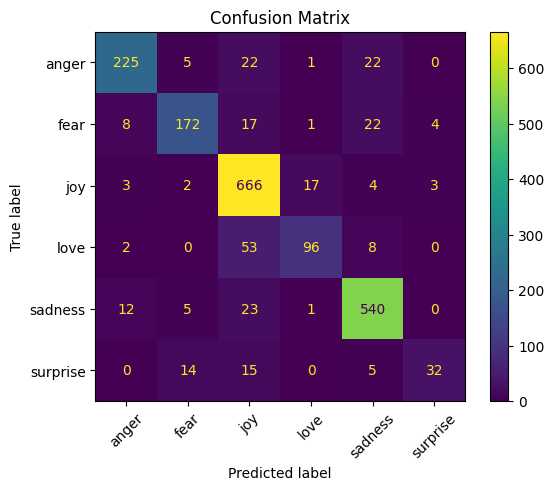

In [42]:
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

### Conclusion

After comparing different models, Logistic Regression was selected as the final model due to its superior performance over Naive Bayes on the validation set.

To make better use of the available data, the model was retrained using both the training and validation sets. The final evaluation was then performed on the test set, which remained completely unseen during the entire process.

The model achieved an accuracy of approximately 85–86% on the test set, confirming its good generalization capability. The slight improvement compared to the validation results is likely due to the larger training dataset.

Overall, the pipeline demonstrates a consistent and reliable approach to text classification, following proper evaluation practices and avoiding data leakage.